In [2]:
### Script for the EDA plot (PCA and tSNE)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [3]:
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)
clin = clin.drop(labels = [1578], axis = 0)
print(clin.shape)

# run a PCA of the data
pca = PCA(n_components=2)
res = pca.fit_transform(prot)

(414, 38)


In [4]:
pca.explained_variance_ratio_

array([0.53691389, 0.11013662])

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


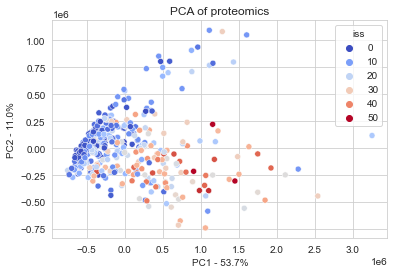

In [5]:
# set a whitegrid
sns.set_style("whitegrid")
plt.title("PCA of proteomics")
sns.scatterplot(res[:,0], res[:,1], hue = clin.iss, palette = 'coolwarm')
plt.xlabel("PC1 - "+ str(pca.explained_variance_ratio_[0].round(3)*100)+ "%")
plt.ylabel("PC2 - "+ str(pca.explained_variance_ratio_[1].round(3)*100)+ "%")
plt.savefig("/Users/smasarone/Documents/pca_raw_data.pdf", format='pdf')


In [6]:
# run a t-sne of the data

tsne = TSNE(n_components=2, random_state=123)
res_t = tsne.fit_transform(prot)

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


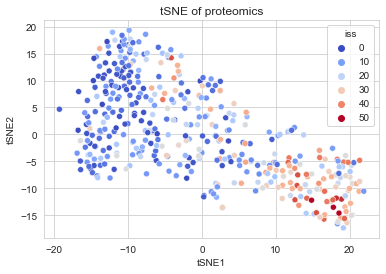

In [18]:
sns.set_style("whitegrid")
plt.title("tSNE of proteomics")
sns.scatterplot(res_t[:,0], res_t[:,1], hue = clin.iss, palette = 'coolwarm')
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.savefig("/Users/smasarone/Documents/tsne_raw_data.pdf", format='pdf')


In [19]:
### Overall we can see that both PCA and tSNE do a good job at stratifying patients by severity group suggesting that the proteomics
### change as a function of injury severity 

4.4
